# Previsão de Entregas: SLE & Monte Carlo
 
[Repositório no GitHub](https://github.com/rodbv/quando-vai-ficar-pronto)  |  [Slides da palestra](https://rodbv.github.io/quando-vai-ficar-pronto/)
 
Este notebook é um companion dos slides da talk **Quando vai ficar pronto?**. Aqui você pode simular previsões de entrega usando seus próprios dados.
 
---
 
## O que este notebook faz
 
- **SLE (Service Level Expectation):** mostra em quantos dias terminamos **1 item** com X% de confiança, usando percentis do lead time histórico.
- **Simulação Monte Carlo:** estima em quantos dias terminamos **N itens** ou quantos itens cabem em N dias, sorteando valores do throughput diário real.
 
> Para detalhes teóricos, consulte os [slides](https://rodbv.github.io/quando-vai-ficar-pronto/).
 
---

In [ ]:
# --- SETUP E IMPORTS ---
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from lib.flow_forecast import (
    cycle_time_days_values,
    daily_throughput,
    monte_carlo_days_to_finish,
    monte_carlo_items_in_days,
    percentiles_from_sim,
    read_items_csv,
    sle_days,
    # outros helpers se necessário
 )

# Previsão de Entregas com SLE e Monte Carlo

Este notebook mostra como responder perguntas de prazo usando dados reais de entregas:

- **SLE (Service Level Expectation):** Em quantos dias entregamos 1 item com X% de confiança?
- **Monte Carlo:** Em quantos dias entregamos N itens? Quantos itens cabem em N dias?

> **Siga as instruções destacadas e rode as células em ordem para obter os resultados.**

## 1. Parâmetros editáveis

Altere os valores abaixo conforme seu cenário. Os valores padrão funcionam para o exemplo incluído.

In [ ]:
# --- Parâmetros principais (edite aqui) ---
CSV_PATH = Path("dados.csv")  # Caminho do arquivo de dados (ajuste se necessário)
CONFIDENCE = 0.85  # Nível de confiança para SLE (ex: 0.85 = 85%)
N_ITEMS = 10       # Quantos itens quer simular na previsão Monte Carlo
N_DAYS = 14        # Prazo fixo para simular quantos itens cabem
RUNS = 10_000      # Quantidade de simulações Monte Carlo
SEED = 42          # Semente aleatória para reprodutibilidade

## 2. Leitura e preview dos dados

O arquivo deve conter ao menos as colunas `started_at` e `finished_at` (datas).

In [ ]:
# --- Leitura dos dados ---
df = read_items_csv(CSV_PATH)
print(f"{len(df)} linhas carregadas de {CSV_PATH}")
display(df.head())

208 linhas carregadas de dados.csv


,started_at,finished_at
0,2026-04-09,2026-04-09
1,2026-04-08,2026-04-09
2,2026-04-06,2026-04-08
3,2026-04-08,2026-04-08
4,2026-04-06,2026-04-07


In [ ]:
# --- Resumo dos dados ---
print("Período dos dados:")
print(f"Início: {df['started_at'].min()}  Fim: {df['finished_at'].max()}")
print(f"Itens entregues: {len(df)}")

Período dos dados:
Início: 2026-01-02 00:00:00  Fim: 2026-04-09 00:00:00
Itens entregues: 208


## 3. SLE (1 item): percentis e Service Level Expectation

O SLE responde: *em quantos dias entregamos 1 item com X% de confiança?*

- Usamos percentis do lead time histórico (ex: P85 = 11 dias → 85% dos itens terminam em até 11 dias).
- O SLE é esse compromisso probabilístico: "nosso SLE atual é X dias @ Y%".

Ajuste o nível de confiança na célula destacada acima.

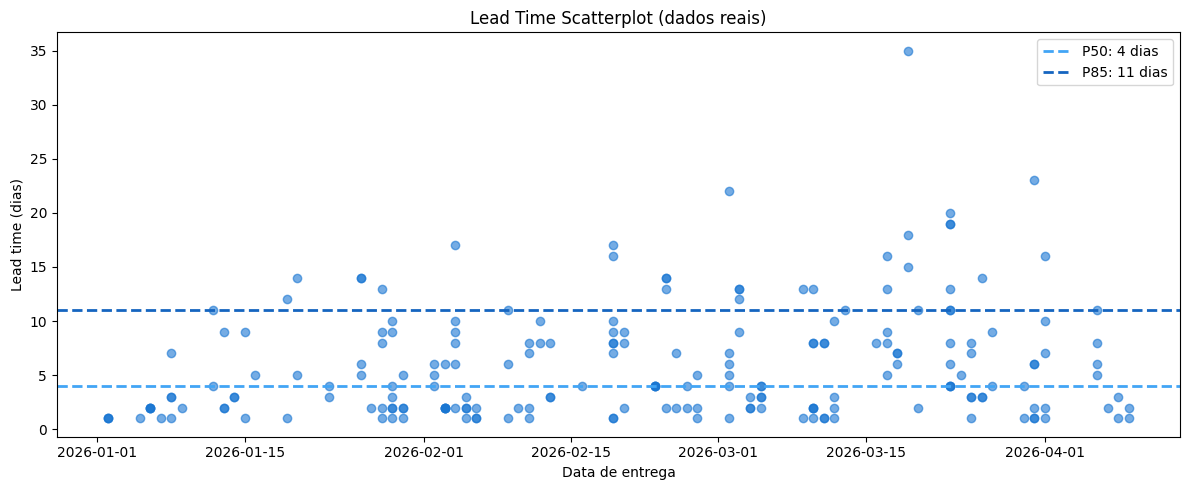


<div style="background:#e3f2fd; border:2px solid #1976d2; padding:16px; font-size:1.2em">
<b>Resultado SLE (1 item):</b><br><br>
<ul>
<li><b>P50:</b> 4 dias</li>
<li><b>P85:</b> 11 dias</li>
<li><b>P95:</b> 16 dias</li>
<li><b>SLE:</b> 11 dias @ 85%</li>
</ul>
<em>Veja acima os valores simulados para o seu cenário.</em>
</div>


In [ ]:
# --- SLE: cálculo e visualização ---
ct = cycle_time_days_values(df)
pcts = {
    50: int(np.percentile(ct, 50)),
    85: int(np.percentile(ct, 85)),
    95: int(np.percentile(ct, 95)),
}
sle = sle_days(ct, confidence=CONFIDENCE)
p50 = np.percentile(ct, 50)
p85 = np.percentile(ct, 85)
plt.figure(figsize=(12, 5))
plt.scatter(df['finished_at'], ct, color="#1976d2", alpha=0.6)
plt.axhline(p50, color="#42a5f5", linestyle="--", lw=2, label=f"P50: {int(p50)} dias")
plt.axhline(p85, color="#1565c0", linestyle="--", lw=2, label=f"P85: {int(p85)} dias")
plt.xlabel("Data de entrega")
plt.ylabel("Lead time (dias)")
plt.title("Lead Time Scatterplot (dados reais)")
plt.legend()
plt.tight_layout()
plt.show()
display(Markdown(f'''
<div style=\"background:#e3f2fd; border:2px solid #1976d2; padding:16px; font-size:1.2em\">
<b>Resultado SLE (1 item):</b><br><br>
<ul>
<li><b>P50:</b> {pcts[50]} dias</li>
<li><b>P85:</b> {pcts[85]} dias</li>
<li><b>P95:</b> {pcts[95]} dias</li>
<li><b>SLE:</b> {sle} dias @ {int(CONFIDENCE*100)}%</li>
</ul>
<em>Veja acima os valores simulados para o seu cenário.</em>
</div>
'''))

## 4. Monte Carlo: previsão para N itens

Agora queremos saber: *em quantos dias entregamos N itens?*

- Usamos simulação Monte Carlo sorteando valores do throughput diário histórico.
- Repete-se a simulação milhares de vezes para obter percentis (P50, P85, P95).

Ajuste o valor de `N_ITEMS` na célula destacada acima.

runs=10000  n_items=10
P50=5 dias  P85=8 dias  P95=10 dias



<div style="background:#e8f5e9; border:2px solid #388e3c; padding:16px; font-size:1.2em">
<b>Resultado Monte Carlo (N itens):</b><br><br>
<ul>
<li><b>P50:</b> 5 dias</li>
<li><b>P85:</b> 8 dias</li>
<li><b>P95:</b> 10 dias</li>
</ul>
<em>Veja acima os valores simulados para o seu cenário.</em>
</div>


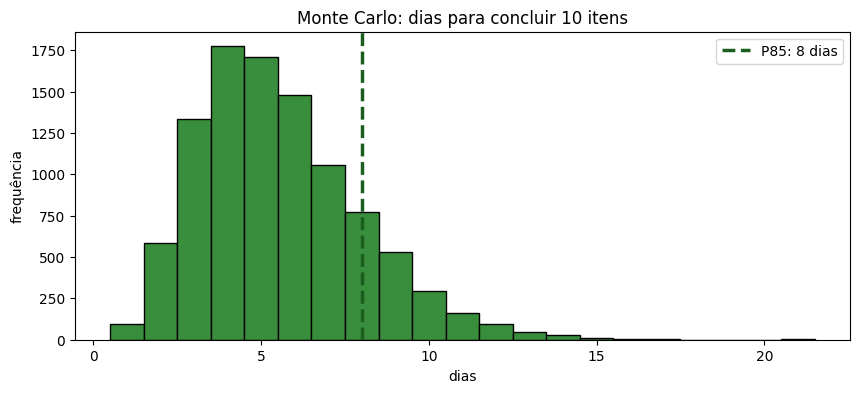

In [ ]:
# --- Monte Carlo: previsão para N itens ---
tp = daily_throughput(df)
sim = monte_carlo_days_to_finish(N_ITEMS, tp, runs=RUNS, seed=SEED)
out = percentiles_from_sim(sim, ps=(50, 85, 95))
print(f"runs={RUNS}  n_items={N_ITEMS}")
print(f"P50={out[50]:.0f} dias  P85={out[85]:.0f} dias  P95={out[95]:.0f} dias")
display(Markdown(f'''
<div style=\"background:#e8f5e9; border:2px solid #388e3c; padding:16px; font-size:1.2em\">
<b>Resultado Monte Carlo (N itens):</b><br><br>
<ul>
<li><b>P50:</b> {out[50]:.0f} dias</li>
<li><b>P85:</b> {out[85]:.0f} dias</li>
<li><b>P95:</b> {out[95]:.0f} dias</li>
</ul>
<em>Veja acima os valores simulados para o seu cenário.</em>
</div>
'''))
plt.figure(figsize=(10, 4))
bins = range(int(sim.min()), int(sim.max()) + 2)
plt.hist(sim, bins=bins, align="left", color="#388e3c", edgecolor="black")
plt.axvline(out[85], color="#1b5e20", linestyle="--", lw=2.5, label=f"P85: {out[85]:.0f} dias")
plt.title(f"Monte Carlo: dias para concluir {N_ITEMS} itens")
plt.xlabel("dias")
plt.ylabel("frequência")
plt.legend()
plt.show()

## 5. Quantos itens cabem em N dias?

Agora a pergunta é: *dado um prazo fixo de N dias, quantos itens conseguimos entregar?*

Ajuste o valor de `N_DAYS` na célula destacada acima.

runs=10000  n_days=14
P15=21 itens  P50=29 itens  P85=38 itens



<div style="background:#ffe0b2; border:2px solid #f57c00; padding:16px; font-size:1.2em">
<b>Resultado Monte Carlo (itens em 14 dias):</b><br><br>
<ul>
<li><b>P15 (85% confiança):</b> <strong>21 itens</strong> — você entrega <strong>pelo menos</strong> este valor</li>
<li><b>P50:</b> 29 itens</li>
<li><b>P85:</b> 38 itens — entrega máxima esperada</li>
</ul>
<em>Percentis invertidos: para "itens em dias", use P15 para 85% de confiança de entregar <strong>pelo menos</strong> este valor.</em>
</div>


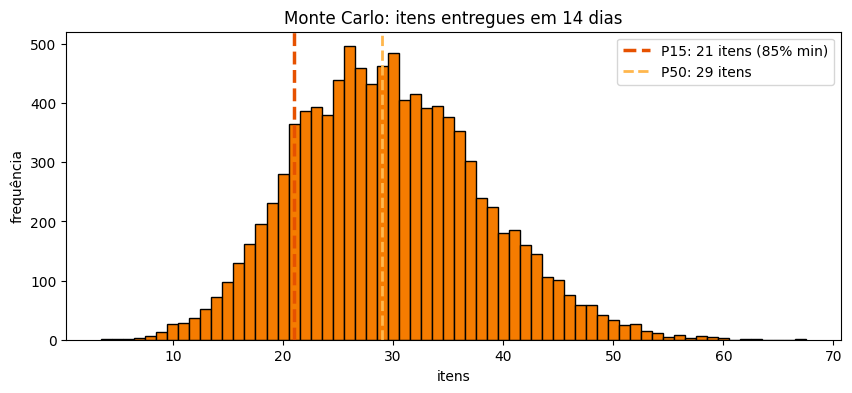

In [ ]:
# --- Monte Carlo: quantos itens em N dias ---
sim_items = monte_carlo_items_in_days(N_DAYS, tp, runs=RUNS, seed=SEED)
out_items = percentiles_from_sim(sim_items, ps=(15, 50, 85))
print(f"runs={RUNS}  n_days={N_DAYS}")
print(f"P15={out_items[15]:.0f} itens  P50={out_items[50]:.0f} itens  P85={out_items[85]:.0f} itens")
display(Markdown(f'''
<div style=\"background:#ffe0b2; border:2px solid #f57c00; padding:16px; font-size:1.2em\">
<b>Resultado Monte Carlo (itens em {N_DAYS} dias):</b><br><br>
<ul>
<li><b>P15 (85% confiança):</b> <strong>{out_items[15]:.0f} itens</strong> — você entrega <strong>pelo menos</strong> este valor</li>
<li><b>P50:</b> {out_items[50]:.0f} itens</li>
<li><b>P85:</b> {out_items[85]:.0f} itens — entrega máxima esperada</li>
</ul>
<em>Percentis invertidos: para "itens em dias", use P15 para 85% de confiança de entregar <strong>pelo menos</strong> este valor.</em>
</div>
'''))
plt.figure(figsize=(10, 4))
bins = range(int(sim_items.min()), int(sim_items.max()) + 2)
plt.hist(sim_items, bins=bins, align="left", color="#f57c00", edgecolor="black")
plt.axvline(out_items[15], color="#e65100", linestyle="--", lw=2.5, label=f"P15: {out_items[15]:.0f} itens (85% min)")
plt.axvline(out_items[50], color="#ffb74d", linestyle="--", lw=2, label=f"P50: {out_items[50]:.0f} itens")
plt.title(f"Monte Carlo: itens entregues em {N_DAYS} dias")
plt.xlabel("itens")
plt.ylabel("frequência")
plt.legend()
plt.show()